In [1]:
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# 1. Data Loading and Preprocessing
def load_data(filepath):
    data = pd.read_csv(filepath, sep='\t', names=['label', 'text'], header=None)
    data['label'] = data['label'].map({'ham': 0, 'spam': 1})
    return data

In [3]:
# Load dataset
sms_data = load_data('SMSSpamCollection')

In [4]:
# Text Preprocessing
max_words = 5000
max_len = 100
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(sms_data['text'])
sequences = tokenizer.texts_to_sequences(sms_data['text'])
X = pad_sequences(sequences, maxlen=max_len)
y = sms_data['label'].values

In [5]:
# Print preprocessing info
print("\nPreprocessing Info:")
print(f"Vocabulary size: {len(tokenizer.word_index) + 1}")
print(f"Sequence length: {max_len}")
print(f"Total samples: {len(X)}")


Preprocessing Info:
Vocabulary size: 9010
Sequence length: 100
Total samples: 5572


In [6]:
# 2. Build the RNN Model using Functional API
vocab_size = min(len(tokenizer.word_index) + 1, max_words)
inputs = tf.keras.Input(shape=(max_len,))
x = tf.keras.layers.Embedding(vocab_size, 128)(inputs)
x = tf.keras.layers.SimpleRNN(64, return_sequences=True)(x)
x = tf.keras.layers.SimpleRNN(32)(x)
x = tf.keras.layers.Dense(16, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
model = tf.keras.Model(inputs=inputs, outputs=outputs)

In [7]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [8]:
# 3. Train the Model
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X, y,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.8963 - loss: 0.2888 - val_accuracy: 0.9776 - val_loss: 0.0758
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9887 - loss: 0.0515 - val_accuracy: 0.9821 - val_loss: 0.0605
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9951 - loss: 0.0258 - val_accuracy: 0.9865 - val_loss: 0.0650
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9950 - loss: 0.0202 - val_accuracy: 0.9803 - val_loss: 0.0710
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9962 - loss: 0.0191 - val_accuracy: 0.9874 - val_loss: 0.0845


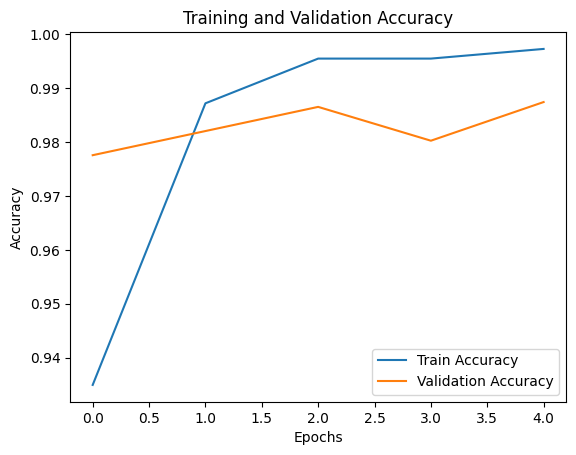

In [9]:
# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

In [15]:
# 4. Make Predictions
def predict_sentiment(text):
    sequence = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(sequence, maxlen=max_len)
    prediction = model.predict(padded)[0][0]
    return {
        'text': text,
        'sentiment': 'Spam' if prediction > 0.5 else 'Ham',
        'confidence': float(prediction if prediction > 0.5 else 1 - prediction)
    }

sample_text = "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"
prediction_result = predict_sentiment(sample_text)
print(prediction_result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
{'text': "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's", 'sentiment': 'Spam', 'confidence': 0.9956715106964111}
